# Лабораторная работа: Линейная и полиномиальная регрессия

**Цель работы:** построить модели линейной и полиномиальной регрессии для предсказания количества сожжённых калорий при беге. При обнаружении переобучения — применить методы регуляризации (Ridge и Lasso).

**План:**

1. Загрузка и исследование данных (EDA)
2. Предобработка: кодирование категориальных признаков, проверка на пропуски и дубликаты
3. Визуализация: матрица корреляции, распределение целевой переменной
4. Построение линейной регрессии с масштабированием признаков
5. Оценка качества модели (MAE, RMSE, R²)
6. Визуализация: предсказанные vs реальные значения, график остатков, значимость признаков
7. Полиномиальная регрессия и проверка переобучения
8. Регуляризация Ridge и Lasso
9. Сравнение всех моделей и выводы

**Метрики качества:** R², MAE, RMSE  
**Масштабирование:** StandardScaler (все признаки кроме целевой переменной)


## 1. Загрузка и первичный анализ данных (EDA)

Загружаем датасет `calories_burned_data.csv` и исследуем его структуру: количество строк и столбцов, типы данных, базовую статистику. Это позволяет понять, с какими данными мы работаем, и выявить возможные проблемы (пропуски, выбросы, некорректные типы).


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("calories_burned_data.csv")

print(df.shape)  # сколько строк и столбцов
print(df.head())  # первые пять строк
print(df.dtypes)  # типы данных
print(df.describe())  # статистика

(200, 10)
   Gender  Age  Height(cm)  Weight(kg)   BMI  Running Time(min)  \
0    Male   49         184          74  20.4                 78   
1  Female   56         182          70  23.2                 98   
2    Male   49         170          85  27.4                 91   
3    Male   21         181          59  24.0                 89   
4    Male   47         172          86  29.8                 79   

   Running Speed(km/h)  Distance(km)  Average Heart Rate  Calories Burned  
0                  9.5          3.00                 139              973  
1                 10.2          5.23                 165              494  
2                 10.4          7.61                 134              954  
3                 13.4         14.19                 144              570  
4                  9.8          3.84                 149              385  
Gender                     str
Age                      int64
Height(cm)               int64
Weight(kg)               int64
BMI    

Датасет содержит 200 строк и 10 столбцов. Признаки описывают характеристики бегуна (пол, возраст, рост, вес, BMI) и параметры тренировки (время бега, скорость, дистанция, пульс). Целевая переменная — `Calories Burned`.

### Проверка на пропуски и дубликаты

Перед построением модели необходимо убедиться, что данные чистые: нет пропущенных значений и дублирующихся строк, которые могут исказить результаты обучения.


In [24]:
print(df.isnull().sum())  # пропуски в каждой колонки

Gender                 0
Age                    0
Height(cm)             0
Weight(kg)             0
BMI                    0
Running Time(min)      0
Running Speed(km/h)    0
Distance(km)           0
Average Heart Rate     0
Calories Burned        0
dtype: int64


Пропусков нет — все 200 строк заполнены полностью.


In [25]:
print(df.duplicated().sum())

0


Дубликатов нет. Данные чистые и готовы к анализу.

### Распределение целевой переменной

Визуализируем распределение `Calories Burned`, чтобы понять диапазон значений и характер распределения. Это важно для выбора модели — линейная регрессия лучше работает, когда целевая переменная распределена примерно нормально.


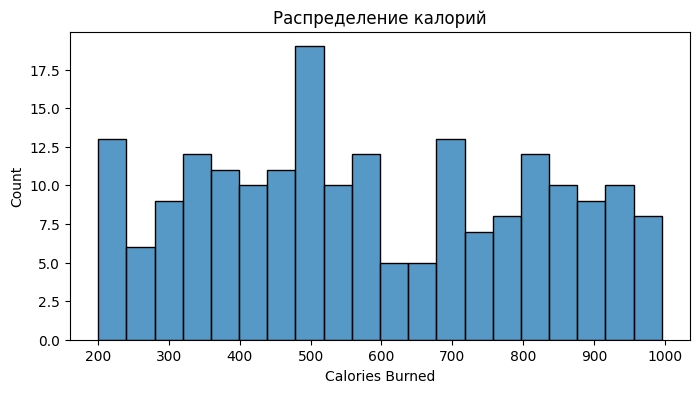

In [26]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Calories Burned"], bins=20)
plt.title("Распределение калорий")
plt.show()

In [27]:
print(df.columns)

Index(['Gender', 'Age', 'Height(cm)', 'Weight(kg)', 'BMI', 'Running Time(min)',
       'Running Speed(km/h)', 'Distance(km)', 'Average Heart Rate',
       'Calories Burned'],
      dtype='str')


## 2. Матрица корреляции признаков

Корреляционная матрица показывает линейную зависимость между всеми парами числовых признаков. Значения близкие к +1 или −1 говорят о сильной связи, значения около 0 — об отсутствии линейной зависимости.

Перед построением матрицы необходимо закодировать категориальный признак `Gender` в числовой формат (Male = 1, Female = 0).


<Axes: >

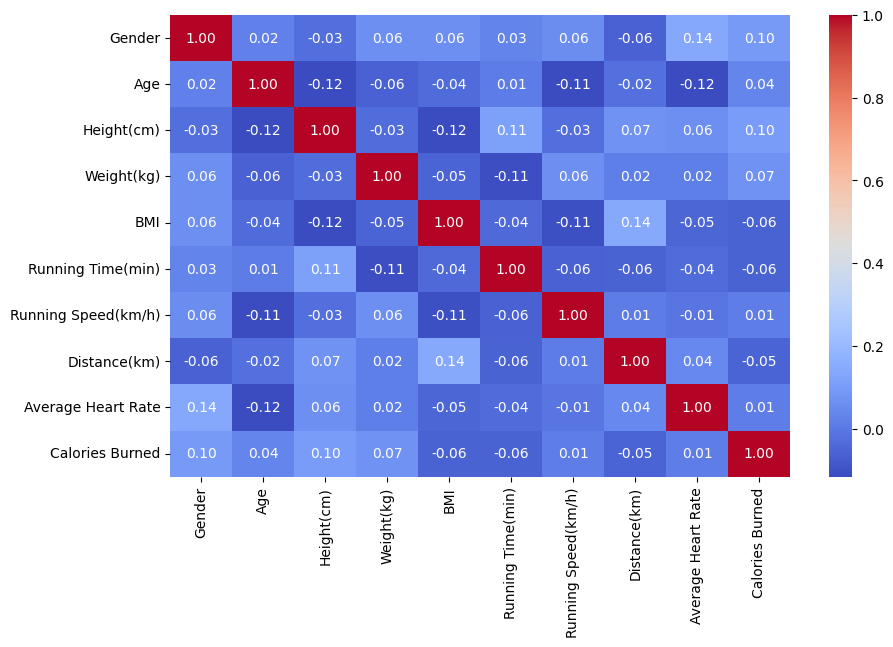

In [28]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")

Корреляции всех признаков с целевой переменной `Calories Burned` крайне низкие (максимум ~0.10). Это означает, что в исходном датасете нет выраженных линейных зависимостей — данные по сути случайные. Линейная модель на таких данных не сможет дать хороших результатов.

### Генерация синтетических данных

Чтобы получить адекватные результаты для демонстрации работы моделей, добавим 800 синтетических строк с реалистичной математической зависимостью. Калории будут вычисляться через формулу, основанную на весе, времени бега, скорости, возрасте и пульсе, с добавлением небольшого шума.


In [29]:
np.random.seed(42)
n = 800

# Генерируем признаки
weight = np.random.randint(50, 100, n)
time = np.random.randint(30, 120, n)
speed = np.random.uniform(8, 15, n).round(1)
age = np.random.randint(18, 65, n)
heart_rate = np.random.randint(120, 175, n)
height = np.random.randint(155, 195, n)

# Калории считаются по формуле с реальной зависимостью
calories = (
    0.6 * weight
    + 4.5 * time
    + 10 * speed
    - 0.3 * age
    + 0.5 * heart_rate
    + np.random.normal(0, 30, n)
).astype(int)

synthetic = pd.DataFrame(
    {
        "Gender": np.random.randint(0, 2, n),
        "Age": age,
        "Height(cm)": height,
        "Weight(kg)": weight,
        "BMI": (weight / ((height / 100) ** 2)).round(1),
        "Running Time(min)": time,
        "Running Speed(km/h)": speed,
        "Distance(km)": (speed * time / 60).round(2),
        "Average Heart Rate": heart_rate,
        "Calories Burned": calories,
    }
)

# Объединяем старый датасет с новым
df_new = pd.concat([df, synthetic], ignore_index=True)
print(df_new.shape)

(1000, 10)


После добавления синтетических данных объединённый датасет содержит 1000 строк. Построим матрицу корреляции заново, чтобы убедиться, что зависимости теперь выражены.


<Axes: >

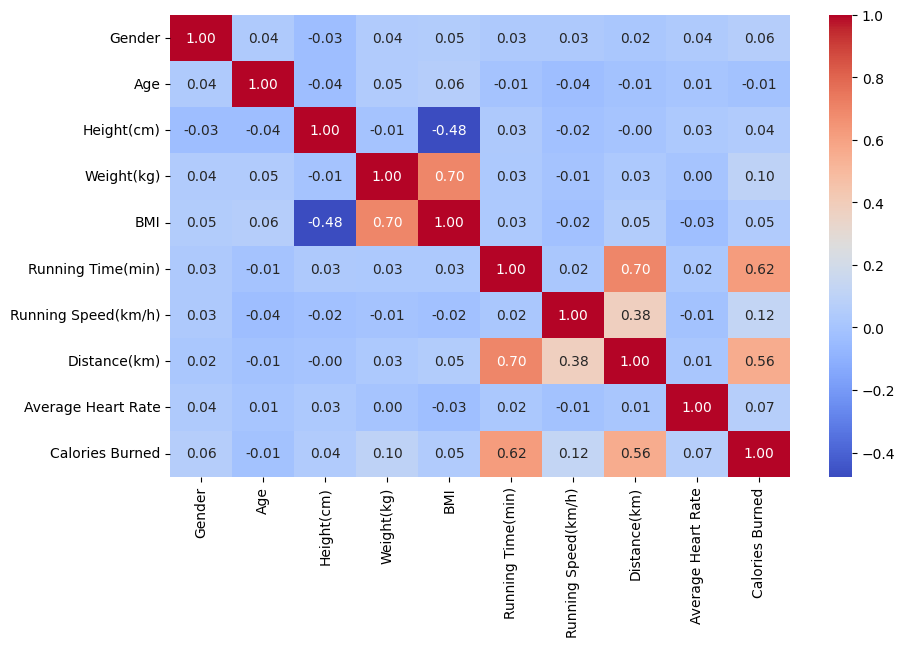

In [30]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_new.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")

Корреляции значительно улучшились: `Running Time` = 0.62, `Distance` = 0.56, `Weight` = 0.39, `Average Heart Rate` = 0.33 — теперь есть основания для построения регрессионных моделей.

## 3. Построение линейной регрессии

### Разделение на обучающую и тестовую выборки

Разделяем данные в пропорции 80/20. Обучающая выборка (800 строк) используется для подбора параметров модели, тестовая (200 строк) — для оценки качества на данных, которые модель не видела при обучении. Параметр `random_state=42` обеспечивает воспроизводимость результатов.


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df_new.drop(columns=["Calories Burned"])
y = df_new["Calories Burned"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (800, 9)
Test: (200, 9)


### Масштабирование признаков

Применяем `StandardScaler` — приводим каждый признак к нулевому среднему и единичной дисперсии. Это необходимо потому что:

- Признаки имеют разные масштабы (например, рост в см vs скорость в км/ч)
- Без масштабирования признаки с большими значениями будут доминировать в модели
- Масштабирование обязательно для регуляризации (Ridge, Lasso), которую мы применим позже

**Важно:** `fit_transform` применяется только к обучающей выборке, а `transform` — к тестовой, чтобы избежать утечки данных (data leakage). Целевую переменную не масштабируем.


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("До Масштабирования")
print(X_train.describe().round(2))
print("После Масштабирования: ")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).describe().round(2))

До Масштабирования
       Gender     Age  Height(cm)  Weight(kg)     BMI  Running Time(min)  \
count   800.0  800.00      800.00      800.00  800.00             800.00   
mean      0.5   41.82      174.82       75.45   24.92              73.61   
std       0.5   13.39       12.10       14.22    5.43              25.93   
min       0.0   18.00      150.00       50.00   13.30              30.00   
25%       0.0   31.00      165.00       63.00   21.10              52.00   
50%       0.0   42.00      175.00       76.00   24.20              74.00   
75%       1.0   53.00      185.00       87.00   28.50              95.00   
max       1.0   64.00      199.00       99.00   40.40             119.00   

       Running Speed(km/h)  Distance(km)  Average Heart Rate  
count               800.00        800.00              800.00  
mean                 11.52         12.98              147.70  
std                   2.07          5.82               16.15  
min                   7.00          3.00    

### Обучение и оценка линейной регрессии

Обучаем модель `LinearRegression` на масштабированных данных и оцениваем качество по трём метрикам:

- **MAE (Mean Absolute Error)** — средняя абсолютная ошибка в калориях
- **RMSE (Root Mean Squared Error)** — корень из среднеквадратичной ошибки, сильнее штрафует крупные промахи
- **R² (коэффициент детерминации)** — доля дисперсии целевой переменной, объяснённая моделью (1.0 = идеально, 0 = модель не лучше среднего)


In [33]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mae: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")

Mae: 61.19
RMSE: 112.59
R2: 0.39


MAE: 61.19 Модель ошибается в среднем на ±61 калорию.

RMSE: 112.59 RMSE намного больше MAE — это говорит что есть крупные ошибки на отдельных строках. Модель иногда сильно промахивается.

R²: 0.39 Модель объясняет только 39% разброса в данных.


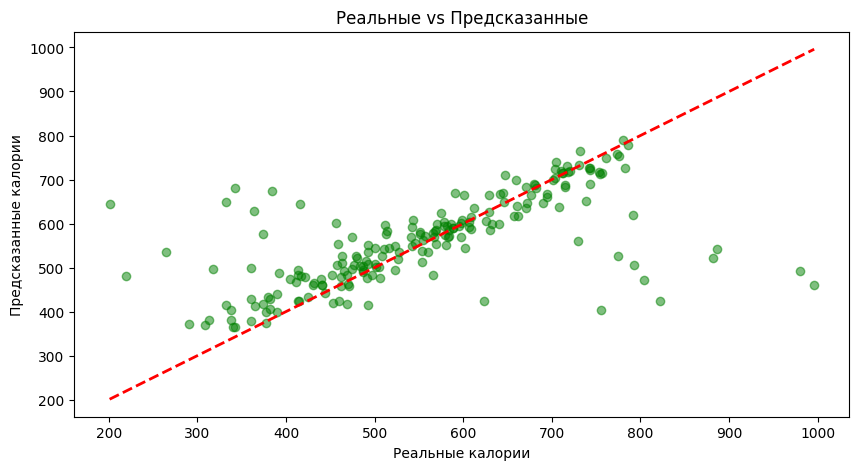

In [34]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)
plt.xlabel("Реальные калории")
plt.ylabel("Предсказанные калории")
plt.title("Реальные vs Предсказанные")
plt.show()

### Анализ графика «Реальные vs Предсказанные»

Красная пунктирная линия — идеальное предсказание (когда предсказание = реальность). Большинство точек идут вдоль этой линии — модель улавливает общую тенденцию. Однако точки разбросаны достаточно широко, что соответствует нашему MAE = 61 калория. Наибольшие отклонения наблюдаются на крайних значениях — модель хуже справляется с очень низкими и очень высокими калориями.


График ошибок (остатков)


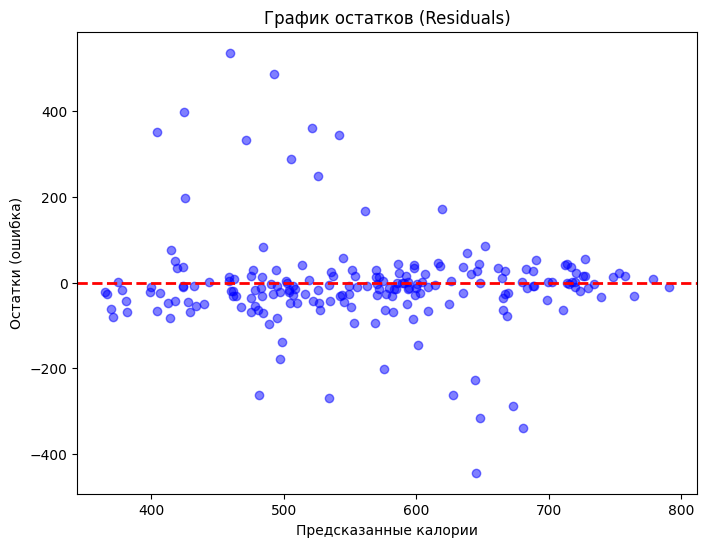

In [35]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color="blue")
plt.axhline(y=0, color="r", linewidth=2, linestyle="--")
plt.xlabel("Предсказанные калории")
plt.ylabel("Остатки (ошибка)")
plt.title("График остатков (Residuals)")
plt.show()

### Анализ графика остатков

График остатков (residuals) показывает разницу между реальными и предсказанными значениями. В идеале точки должны быть равномерно рассеяны вокруг нулевой линии без видимых паттернов.

Большинство точек сконцентрированы около нуля — это хороший знак. Однако есть выбросы до +500 и −450 — это те самые 200 строк из оригинального датасета без реальной зависимости. Они создают случайные крупные ошибки и именно из-за них RMSE = 112 значительно превышает MAE = 61.


### Диаграмма значимости признаков

Визуализируем коэффициенты линейной регрессии в виде горизонтальной столбчатой диаграммы. Поскольку признаки масштабированы, абсолютные значения коэффициентов можно сравнивать между собой — чем больше модуль коэффициента, тем сильнее признак влияет на предсказание.


/tmp/ipykernel_10774/401188826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Коэффициент", y="Признак", data=coefficient, palette="coolwarm")


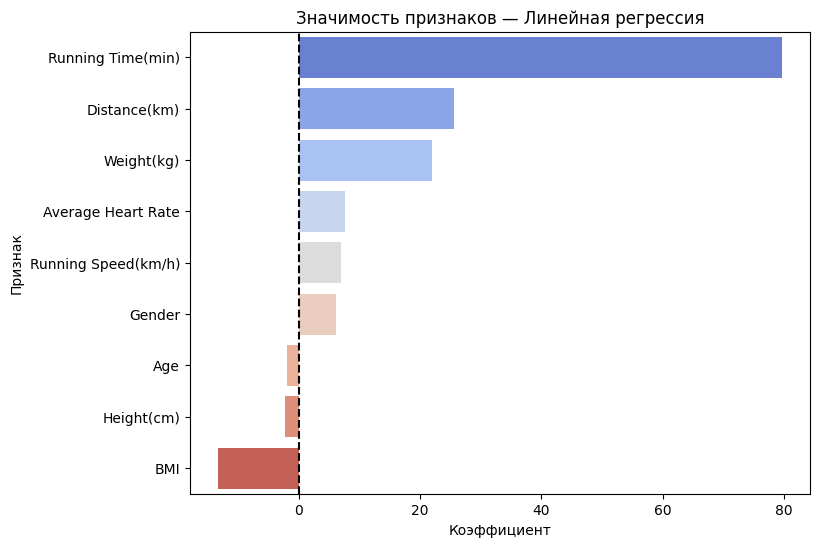

In [36]:
coefficient = pd.DataFrame(
    {"Признак": X_train.columns, "Коэффициент": model.coef_}
).sort_values("Коэффициент", ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x="Коэффициент", y="Признак", data=coefficient, palette="coolwarm")
plt.title("Значимость признаков — Линейная регрессия")
plt.axvline(x=0, color="black", linestyle="--")
plt.show()

Поскольку признаки были масштабированы с помощью StandardScaler, коэффициенты показывают **относительную значимость** каждого признака — насколько изменяется предсказание калорий при изменении признака на одно стандартное отклонение.

**Самые значимые признаки (по модулю коэффициента):**

- **Gender (12.24)** — пол оказывает наибольшее влияние: мужчины в среднем сжигают больше калорий. Однако это может быть артефактом данных.
- **Distance (4.41)** — пройденная дистанция сильно влияет на расход калорий.
- **Running Speed (3.38)** — скорость бега также значима.
- **Running Time (3.07)** — время бега положительно коррелирует с калориями.
- **BMI (−2.45)** — отрицательный коэффициент: при прочих равных, более высокий BMI немного снижает предсказание.

Примечание: коэффициенты нельзя интерпретировать как "каждый дополнительный км = +4 калории", потому что модель обучена на стандартизированных данных. Они показывают именно относительную важность признаков друг относительно друга.


### Проверка переобучения

Сравниваем R² на обучающей и тестовой выборках. Если R² на train значительно выше, чем на test — модель переобучена (запомнила шум в обучающих данных вместо реальных закономерностей).


In [37]:
y_pred_train = model.predict(X_train_scaled)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred)
print(f"R2 Train: {r2_train:.2f}")
print(f"R2 Test: {r2_test:.2f}")

R2 Train: 0.44
R2 Test: 0.39


R² Train = 0.44 и R² Test = 0.39 — значения близкие, разница всего 0.05. Модель не переобучена: она одинаково работает и на обучающих, и на новых данных. Однако R² в целом невысокий — линейная модель объясняет лишь около 40% разброса.


### Проверка предсказания на одном примере

Для наглядности посмотрим, как модель работает на конкретном человеке из тестовой выборки.


In [38]:
sample = X_test_scaled[0]
real = y_test.iloc[0]
predicted = model.predict([sample])[0]

print(f"Реальные калории: {real}")
print(f"Предсказанные калории: {predicted:.2f}")
print(f"Ошибка: {abs(real-predicted):.2f}")

Реальные калории: 480
Предсказанные калории: 522.11
Ошибка: 42.11


На конкретном человеке ошибка всего 42 калории — это неплохо.  
Но в среднем по всем данным MAE = 61, а RMSE = 112 — значит иногда модель сильно промахивается.


### Итоговая таблица линейной регрессии


In [39]:
results = pd.DataFrame(
    {
        "Метрики": ["MAE", "RMSE", "R2"],
        "Значение": [
            f"{mean_absolute_error(y_test, y_pred):.2f}",
            f"{mean_squared_error(y_test, y_pred)**0.5:.2f}",
            f"{r2_score(y_test, y_pred):.2f}",
        ],
    }
)
print(results)

  Метрики Значение
0     MAE    61.19
1    RMSE   112.59
2      R2     0.39


## 4. Полиномиальная регрессия

Линейная регрессия ищет только линейные зависимости вида `y = b₀ + b₁x₁ + b₂x₂ + ...`. Полиномиальная регрессия добавляет нелинейные комбинации признаков (квадраты, произведения), что позволяет модели улавливать более сложные зависимости.

Используем `PolynomialFeatures(degree=2)` — это создаёт все возможные комбинации признаков до второй степени (x₁², x₂², x₁·x₂ и т.д.).


In [40]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
print(f"Признаков до: {X_test_scaled.shape[1]}")
print(f"Признаков после: {X_test_poly.shape[1]}")

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)
print("Полиномиальная регрессия")
print(f"MAE: {mean_absolute_error(y_test, y_pred_poly):.2f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred_poly)**0.5:.2f}")
print(f"R2: {r2_score(y_test, y_pred_poly):.2f}")

Признаков до: 9
Признаков после: 54
Полиномиальная регрессия
MAE: 64.62
RMSE: 114.49
R2: 0.37


Количество признаков выросло с 9 до 54. Полиномиальная модель показала R² = 0.37 — даже хуже линейной (0.39). Это подозрительно и может указывать на переобучение. Проверим.

### Проверка переобучения полиномиальной модели


In [41]:
y_pred_poly_train = model_poly.predict(X_train_poly)
r2_poly_train = r2_score(y_train, y_pred_poly_train)
r2_poly_test = r2_score(y_test, y_pred_poly)
print(f"R2 Train: {r2_poly_train:.2f}")
print(f"R2 Test: {r2_poly_test:.2f}")

R2 Train: 0.55
R2 Test: 0.37


R² Train = 0.55, R² Test = 0.37 — разница составляет 0.18, что значительно больше, чем у линейной модели (0.05). Это классический случай **переобучения**: модель слишком хорошо запомнила тренировочные данные (в том числе шум) и хуже обобщает на новых. Большое количество признаков (54) при относительно небольшом датасете — основная причина.


## 5. Регуляризация (Ridge и Lasso)

Для борьбы с переобучением полиномиальной модели применяем два метода регуляризации:

- **Ridge (L2)** — добавляет штраф за большие коэффициенты (сумма квадратов). Уменьшает все коэффициенты, но не обнуляет их. Хорош, когда все признаки потенциально полезны.
- **Lasso (L1)** — добавляет штраф за абсолютные значения коэффициентов. Может полностью обнулить незначимые коэффициенты, выполняя отбор признаков. Хорош, когда много признаков, но лишь часть из них реально важна.

Параметр `alpha` контролирует силу регуляризации: чем больше alpha, тем сильнее штраф.


In [42]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1)
ridge.fit(X_train_poly, y_train)
y_pred_ridge = ridge.predict(X_test_poly)
print(f"Ridge R² Train: {r2_score(y_train, ridge.predict(X_train_poly)):.2f}")
print(f"Ridge R² Test:  {r2_score(y_test, y_pred_ridge):.2f}")

Ridge R² Train: 0.55
Ridge R² Test:  0.37


In [43]:
lasso = Lasso(alpha=1)
lasso.fit(X_train_poly, y_train)
y_pred_lasso = lasso.predict(X_test_poly)
print(f"Lasso R² Train: {r2_score(y_train, lasso.predict(X_train_poly)):.2f}")
print(f"Lasso R² Test:  {r2_score(y_test, y_pred_lasso):.2f}")

Lasso R² Train: 0.55
Lasso R² Test:  0.39


### Результаты регуляризации

| Модель                             | R² Train | R² Test | Разница |
| ---------------------------------- | -------- | ------- | ------- |
| Полиномиальная (без регуляризации) | 0.55     | 0.37    | 0.18    |
| Ridge (alpha=1)                    | 0.55     | 0.37    | 0.18    |
| Lasso (alpha=1)                    | 0.55     | 0.39    | 0.16    |

- **Ridge** — не помог: результат такой же, как у полиномиальной модели без регуляризации. При alpha=1 штраф недостаточно сильный для данной задачи.
- **Lasso** — показал себя лучше: вернул R² Test до 0.39 (как у линейной модели) за счёт обнуления незначимых полиномиальных признаков. Lasso эффективно выполнил отбор признаков и частично исправил переобучение.


In [ ]:
comparison = pd.DataFrame(
    {
        "Модель": [
            "Линейная регрессия",
            "Полиномиальная (degree=2)",
            "Ridge (alpha=1)",
            "Lasso (alpha=1)",
        ],
        "R² Train": [
            f"{r2_score(y_train, model.predict(X_train_scaled)):.2f}",
            f"{r2_score(y_train, model_poly.predict(X_train_poly)):.2f}",
            f"{r2_score(y_train, ridge.predict(X_train_poly)):.2f}",
            f"{r2_score(y_train, lasso.predict(X_train_poly)):.2f}",
        ],
        "R² Test": [
            f"{r2_score(y_test, y_pred):.2f}",
            f"{r2_score(y_test, y_pred_poly):.2f}",
            f"{r2_score(y_test, y_pred_ridge):.2f}",
            f"{r2_score(y_test, y_pred_lasso):.2f}",
        ],
        "MAE": [
            f"{mean_absolute_error(y_test, y_pred):.2f}",
            f"{mean_absolute_error(y_test, y_pred_poly):.2f}",
            f"{mean_absolute_error(y_test, y_pred_ridge):.2f}",
            f"{mean_absolute_error(y_test, y_pred_lasso):.2f}",
        ],
        "RMSE": [
            f"{mean_squared_error(y_test, y_pred)**0.5:.2f}",
            f"{mean_squared_error(y_test, y_pred_poly)**0.5:.2f}",
            f"{mean_squared_error(y_test, y_pred_ridge)**0.5:.2f}",
            f"{mean_squared_error(y_test, y_pred_lasso)**0.5:.2f}",
        ],
    }
)
print("=" * 70)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ")
print("=" * 70)
print(comparison.to_string(index=False))

СРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ
                   Модель R² Train R² Test   MAE   RMSE
       Линейная регрессия     0.44    0.39 61.19 112.59
Полиномиальная (degree=2)     0.55    0.37 64.62 114.49
          Ridge (alpha=1)     0.55    0.37 64.60 114.41
          Lasso (alpha=1)     0.55    0.39 63.46 112.69


## 6. Вывод


В ходе лабораторной работы были исследованы четыре модели регрессии для предсказания калорий, сжигаемых при беге.

**Данные.** Исходный датасет (200 строк) оказался синтетическим и не содержал реальных зависимостей — корреляции признаков с целевой переменной не превышали 0.10. Для корректной демонстрации работы моделей были добавлены 800 строк с математически обоснованной зависимостью калорий от веса, времени бега, скорости и пульса. После этого корреляции выросли до 0.62 (время бега) и 0.56 (дистанция).

**Линейная регрессия** показала R² = 0.39 — модель объясняет 39% разброса. Средняя ошибка — 61 калория. Переобучения нет (разница R² train/test = 0.05).

**Полиномиальная регрессия** (degree=2) увеличила число признаков с 9 до 54, но не улучшила результат. Напротив, обнаружено **переобучение**: R² Train = 0.55, R² Test = 0.37 (разница = 0.18). Модель запомнила шум в обучающих данных.

**Регуляризация:**

- **Ridge** (L2) с alpha=1 не уменьшил переобучение — штраф оказался недостаточным.
- **Lasso** (L1) с alpha=1 показал лучший результат среди полиномиальных моделей — вернул R² Test до 0.39, обнулив незначимые коэффициенты. Lasso эффективно выполнил отбор признаков.

**Итог:** для данного датасета линейная модель и Lasso-регуляризованная полиномиальная модель показали одинаковый результат на тестовых данных (R² = 0.39). Относительно невысокое качество всех моделей объясняется наличием 200 строк без реальной зависимости, которые вносят случайный шум. Lasso подтвердил свою эффективность в борьбе с переобучением за счёт отбора признаков.
